In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt # plots

from PIL import Image # image
from tensorflow.keras.preprocessing.image import ImageDataGenerator # pre-processing
from keras import layers, models, optimizers # modeling

In [2]:
# Path to data

train_dir =r'C:\Users\prasa\OneDrive\Desktop\final dataset\Train\Tongue'
test_dir = r'C:\Users\prasa\OneDrive\Desktop\final dataset\Test\Tongue'
val_dir = r'C:\Users\prasa\OneDrive\Desktop\final dataset\Valid\Tongue'

In [4]:
# Loading images from directory using generator
train_datagen = ImageDataGenerator(rescale=1./255) 
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical' # We only have 2 classes, so class_mode will be 'binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=4,
    class_mode='categorical'
)

Found 381 images belonging to 2 classes.
Found 85 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


In [5]:
# Sanity check
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (20, 224, 224, 3)
labels batch shape: (20, 2)


## Baseline Model - Convolutional Neural Network

In [10]:
model = models.Sequential() 
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3))) 
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu')) 
model.add(layers.MaxPooling2D((2, 2))) 
model.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model.add(layers.MaxPooling2D((2, 2))) 
model.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model.add(layers.MaxPooling2D((2, 2))) 
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu')) 
model.add(layers.Dense(2, activation='sigmoid'))

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,679,554 (36.92 MB)

 Trainable params: 9,679,554 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Create a callback to save the model after each epoch
checkpoint_callback = ModelCheckpoint(
    'Tongue_epoch_{epoch:02d}.keras',  # Save the model with the epoch number in the filename
    save_best_only=False,  # Save all models after each epoch (not just the best)
    save_weights_only=False,  # Save the entire model (architecture + weights)
    verbose=1  # Print messages when saving the model
)

history = model.fit(
    train_generator,  # Use your training data generator
    epochs=150,
    validation_data=val_generator,
    validation_steps=4,
    callbacks=[checkpoint_callback]  # Add the callback here
)


Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - acc: 0.4762 - loss: 0.7021
Epoch 1: saving model to Tongue_epoch_01.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 478ms/step - acc: 0.4773 - loss: 0.7019 - val_acc: 0.3750 - val_loss: 0.7103
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - acc: 0.5625 - loss: 0.6768
Epoch 2: saving model to Tongue_epoch_02.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - acc: 0.5617 - loss: 0.6770 - val_acc: 0.6250 - val_loss: 0.6649
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - acc: 0.5764 - loss: 0.6689
Epoch 3: saving model to Tongue_epoch_03.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - acc: 0.5748 - loss: 0.6692 - val_acc: 0.7500 - val_loss: 0.5698
Epoch 4/150
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - acc: 0.5822 - loss: 0.6547
Epoch 4: saving model to Tongue_epoch_04.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - acc: 0.5808 - loss: 0.6556 - val_acc: 0.3125 - val_loss: 0.8205
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - 

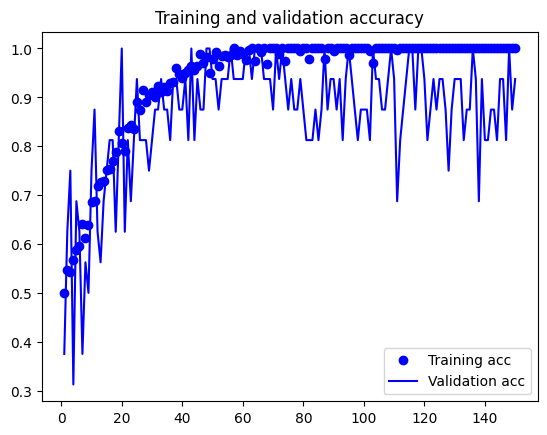

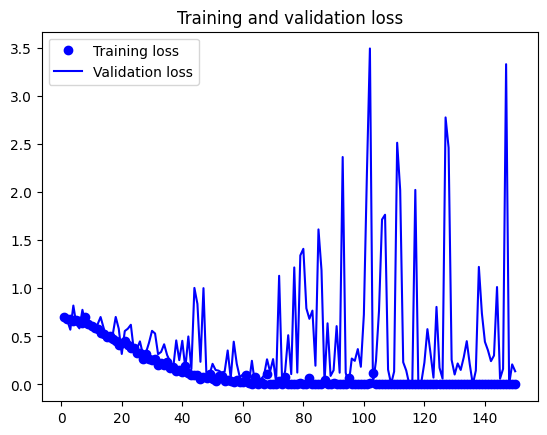

In [14]:
import matplotlib.pyplot as plt
acc = history.history['acc']
val_acc = history.history['val_acc'] 
loss = history.history['loss'] 
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc') 
plt.plot(epochs, val_acc, 'b', label='Validation acc') 
plt.title('Training and validation accuracy') 
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss') 
plt.plot(epochs, val_loss, 'b', label='Validation loss') 
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [15]:
from tensorflow.keras.models import load_model

# Load the saved model (replace 'model_epoch_14.h5' with your saved model's file name)
model = load_model('Tongue_epoch_150.keras')

# Evaluate the model on your test data
# Assuming you have a test data generator (test_generator) for your test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator))

# Print the test accuracy
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - acc: 0.9082 - loss: 0.3889
Test Accuracy: 90.59%


In [ ]:
model = keras
test_loss, test_acc = model.evaluate(test_generator) 
print('test acc:', test_acc)

c:\Users\AKHIL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 485ms/step - acc: 0.7387 - loss: 2.7298
test acc: 0.738095223903656


In [32]:
model.save('baseline_cnn.h5')

We achieved an accuracy of **88.0%** in the test set.

## Image Augmentation

We will apply data augmentation in order to increase the size of the training set. For that, we will create a new Train ImageDataGenerator object.

In [33]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                  rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical' # We only have 2 classes, so class_mode will be 'binary'
)

Found 297 images belonging to 3 classes.


In [42]:
model2 = models.Sequential() 
model2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3))) 
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Conv2D(64, (3, 3), activation='relu')) 
model2.add(layers.MaxPooling2D((2, 2))) 
model2.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model2.add(layers.MaxPooling2D((2, 2))) 
model2.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model2.add(layers.MaxPooling2D((2, 2))) 
model2.add(layers.Flatten())
model2.add(layers.Dense(512, activation='relu')) 
model2.add(layers.Dense(3, activation='sigmoid'))

In [43]:
model2.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

history2 = model2.fit(train_generator,
                                steps_per_epoch=100,
                                epochs=8,
                                validation_data=val_generator,
                                validation_steps=4)

Epoch 1/8
 15/100 ━━━━━━━━━━━━━━━━━━━━ 1:30 1s/step - acc: 0.5001 - loss: 0.9801

c:\Users\DELL\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - acc: 0.4900 - loss: 0.9638 - val_acc: 0.3125 - val_loss: 0.8144
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 156ms/step - acc: 0.5433 - loss: 0.9387 - val_acc: 0.5000 - val_loss: 0.9153
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - acc: 0.5281 - loss: 0.9310 - val_acc: 0.5625 - val_loss: 0.8733
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - acc: 0.5337 - loss: 0.9355 - val_acc: 0.5625 - val_loss: 0.9540
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - acc: 0.5289 - loss: 0.9388 - val_acc: 0.5000 - val_loss: 1.1021
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - acc: 0.5428 - loss: 0.9241 - val_acc: 0.4375 - val_loss: 0.8093
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - acc: 0.5422 - loss: 0.9286 - val_acc: 0.6250 - val_loss: 1.0301
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - acc: 0.5379 - loss: 0.9310 - val_acc: 0.5625 - val_loss: 0.8955


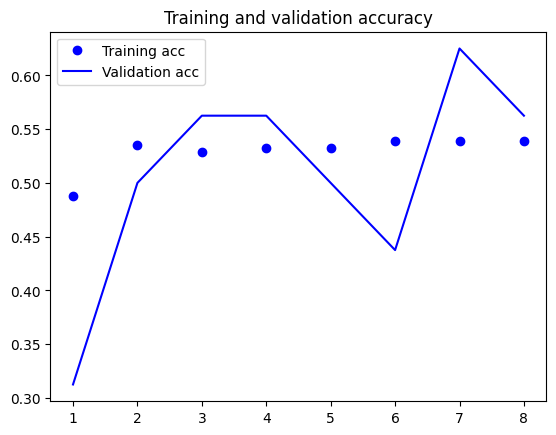

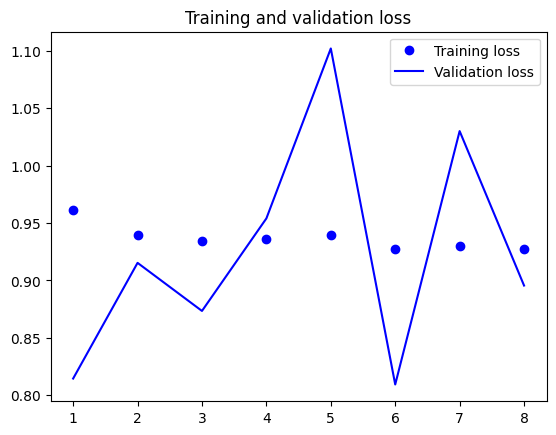

In [44]:
acc = history2.history['acc']
val_acc = history2.history['val_acc'] 
loss = history2.history['loss'] 
val_loss = history2.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc') 
plt.plot(epochs, val_acc, 'b', label='Validation acc') 
plt.title('Training and validation accuracy') 
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss') 
plt.plot(epochs, val_loss, 'b', label='Validation loss') 
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [46]:
test_loss, test_acc = model2.generator(test_generator, steps=50) 
print('test acc:', test_acc)

AttributeError: 'Sequential' object has no attribute 'generator'

In [44]:
model.save('/kaggle/working/cnn_augmented.h5')

Now, we got an accuracy of **84.3%** in the test set

## Adding Dropout

Now, let's add some dropout layers to the previous network in order to reduce overfitting.

In [26]:
model3 = models.Sequential() 
model3.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3))) 
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Conv2D(64, (3, 3), activation='relu')) 
model3.add(layers.MaxPooling2D((2, 2))) 
model3.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model3.add(layers.MaxPooling2D((2, 2))) 
model3.add(layers.Conv2D(128, (3, 3), activation='relu')) 
model3.add(layers.MaxPooling2D((2, 2))) 
model3.add(layers.Flatten())
model3.add(layers.Dropout(0.2))
model3.add(layers.Dense(512, activation='relu')) 
model3.add(layers.Dense(1, activation='sigmoid'))

In [28]:
model3.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

history3 = model3.fit_generator(train_generator,
                                steps_per_epoch=100,
                                epochs=9,
                                validation_data=val_generator,
                                validation_steps=4)

Epoch 1/9
100/100 [==============================] - 60s 605ms/step - loss: 0.2686 - acc: 0.8853 - val_loss: 0.3688 - val_acc: 0.8125
Epoch 2/9
100/100 [==============================] - 65s 647ms/step - loss: 0.2454 - acc: 0.8865 - val_loss: 1.3524 - val_acc: 0.5625
Epoch 3/9
100/100 [==============================] - 58s 583ms/step - loss: 0.2519 - acc: 0.8968 - val_loss: 0.4852 - val_acc: 0.6875
Epoch 4/9
100/100 [==============================] - 56s 561ms/step - loss: 0.2182 - acc: 0.9065 - val_loss: 0.6350 - val_acc: 0.6875
Epoch 5/9
100/100 [==============================] - 56s 556ms/step - loss: 0.2703 - acc: 0.8895 - val_loss: 0.5332 - val_acc: 0.7500
Epoch 6/9
100/100 [==============================] - 53s 535ms/step - loss: 0.2406 - acc: 0.8893 - val_loss: 1.2132 - val_acc: 0.5625
Epoch 7/9
100/100 [==============================] - 47s 467ms/step - loss: 0.2398 - acc: 0.9025 - val_loss: 0.9583 - val_acc: 0.6250
Epoch 8/9
100/100 [==============================] - 52s 516ms

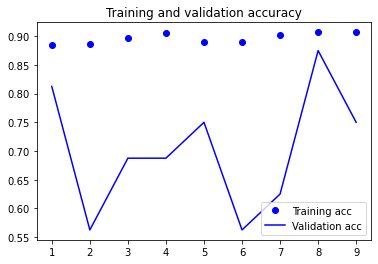

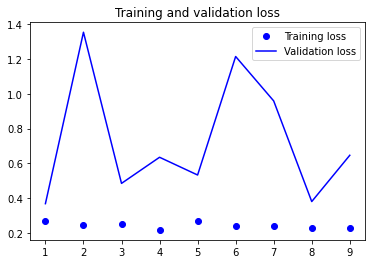

In [29]:
acc = history3.history['acc']
val_acc = history3.history['val_acc'] 
loss = history3.history['loss'] 
val_loss = history3.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc') 
plt.plot(epochs, val_acc, 'b', label='Validation acc') 
plt.title('Training and validation accuracy') 
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss') 
plt.plot(epochs, val_loss, 'b', label='Validation loss') 
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [31]:
test_loss, test_acc = model3.evaluate_generator(test_generator, steps=50) 
print('test acc:', test_acc)

test acc: 0.8942307829856873


In [32]:
model.save('/kaggle/working/cnn_augmented_dropout.h5')

We got an accuracy of **89.4%**.

# Transfer Learning

With the previous solutions, the maximum accuracy we reached was **89.4%**. Now, let's try something different. We will use a pre-trained neural network to see if we get better results.